In [22]:
import pyreadstat
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Explanatory Data Analysis

In [23]:
df_ch = pyreadstat.read_sav('C:/Users/dbastola2022/OneDrive - Florida Atlantic University/Academics/Research/Malnutrition/NDHS/Work Progress/Python/malnutrition/MICS/ch.sav')[0]
# data = pd.read_spss('/workspaces/malnutrition/MICS/ch.sav')

# df_bh = pyreadstat.read_sav('/workspaces/malnutrition/MICS/bh.sav')[0]
# df_hh = pyreadstat.read_sav('/workspaces/malnutrition/MICS/hh.sav')[0]
# df_wm = pyreadstat.read_sav('/workspaces/malnutrition/MICS/wm.sav')[0]
# df_fs = pyreadstat.read_sav('/workspaces/malnutrition/MICS/fs.sav')[0]
# df_mn = pyreadstat.read_sav('/workspaces/malnutrition/MICS/mn.sav')[0]
# df_hl = pyreadstat.read_sav('/workspaces/malnutrition/MICS/hl.sav')[0]


In [24]:
df_ch.head(2)

,HH1,HH2,LN,UF1,UF2,UF3,UFINT,UF4,UF5,UF6,...,wscoreu,windex5u,windex10u,wscorer,windex5r,windex10r,ListCat,PSU,dstratum,stratum
0,1.0,3.0,5.0,1.0,3.0,5.0,103.0,4.0,103.0,100.0,...,NaN,NaN,NaN,-0.831559,2.0,3.0,1.0,1.0,11.1,1.1
1,1.0,5.0,5.0,1.0,5.0,5.0,104.0,2.0,104.0,100.0,...,NaN,NaN,NaN,-1.220021,1.0,2.0,1.0,1.0,11.1,1.1


In [25]:
# df_ch.to_csv('/workspaces/malnutrition/MICS/df_ch.csv', index=False)

In [26]:
print(df_ch.shape)
# print(df_hl.shape)
# print(df_bh.shape)
# print(df_wm.shape)
# print(df_hh.shape)
# print(df_fs.shape)
# print(df_mn.shape)

(6749, 449)


### Renaming the columns

In [27]:
df1 = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = df1.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})
df1.head()

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,underweight,stunting,wasting
0,1.0,7.8,1.0,2.0,2.0,2.0,1.0,5.0,2.0,1.0,1.0,-2.94,-3.53,-1.69
1,3.0,12.5,NaN,2.0,1.0,2.0,1.0,5.0,2.0,1.0,1.0,-1.93,-2.58,-0.65
2,2.0,11.1,1.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,-1.45,-1.07,-1.27
3,1.0,9.3,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,-0.98,-0.90,-0.74
4,4.0,14.7,NaN,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,-1.35,-1.67,-0.45


In [28]:
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

# Remove rows with coded entries in each column
df2 = df1.copy()
df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# df2.to_csv('/workspaces/malnutrition/MICS/df2.csv', index=False)

### Convert to Binary Response Variables

In [29]:
df2.dropna(inplace=True)

df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]

df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)
df2.head(10)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1.0,7.8,1.0,2.0,2.0,2.0,1.0,5.0,2.0,1.0,1.0,1
2,2.0,11.1,1.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,0
3,1.0,9.3,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,0
5,0.0,6.9,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,0
6,1.0,10.5,1.0,2.0,2.0,2.0,1.0,5.0,2.0,1.0,1.0,0
7,1.0,10.4,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,0
10,1.0,8.8,1.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1
13,1.0,9.7,1.0,2.0,2.0,2.0,1.0,0.0,2.0,1.0,1.0,1
15,1.0,10.3,1.0,2.0,2.0,2.0,1.0,5.0,2.0,1.0,1.0,1
16,1.0,7.7,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1


In [30]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3581 entries, 0 to 6747
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   child_age               3581 non-null   float64
 1   child_weight            3581 non-null   float64
 2   ever_breastfed          3581 non-null   float64
 3   diarrhoea_last_2_weeks  3581 non-null   float64
 4   fever_last_2_weeks      3581 non-null   float64
 5   area                    3581 non-null   float64
 6   child_sex               3581 non-null   float64
 7   mother_education        3581 non-null   float64
 8   health_insurance        3581 non-null   float64
 9   province                3581 non-null   float64
 10  wealth_index            3581 non-null   float64
 11  malnurished             3581 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 363.7 KB


In [31]:
print(df2['malnurished'].value_counts())

malnurished
0    1985
1    1596
Name: count, dtype: int64


In [32]:
df2['child_age'].value_counts() # Child age is also categorical, not numerical

child_age
1.0    1269
2.0    1260
0.0    1052
Name: count, dtype: int64

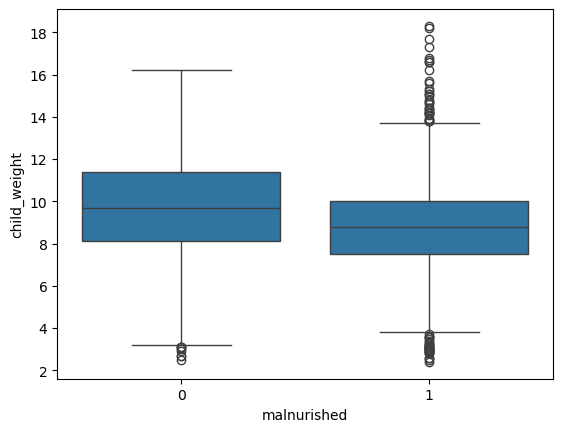

In [33]:
sns.boxplot(x='malnurished', y='child_weight',  data=df2)
plt.show()

## Feature Importance Check for Categorical Features

### Contingency table for categorical features

In [34]:
# Listing all categorical features
cat_columns = ['child_age', 'ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'mother_education', 'health_insurance', 'province', 'wealth_index']

# Contingency table for categorical features
contingency_tables = {}
for col in cat_columns:
    contingency_tables[col] = pd.crosstab(df2[col], df2['malnurished'])
    print(f"Contingency table for {col}:\n{contingency_tables[col]}\n")

Contingency table for child_age:
malnurished    0    1
child_age            
0.0          657  395
1.0          663  606
2.0          665  595

Contingency table for ever_breastfed:
malnurished        0     1
ever_breastfed            
1.0             1843  1480
2.0              142   116

Contingency table for diarrhoea_last_2_weeks:
malnurished                0     1
diarrhoea_last_2_weeks            
1.0                      225   211
2.0                     1760  1385

Contingency table for fever_last_2_weeks:
malnurished            0     1
fever_last_2_weeks            
1.0                  470   364
2.0                 1515  1232

Contingency table for area:
malnurished     0    1
area                  
1.0          1159  809
2.0           826  787

Contingency table for child_sex:
malnurished     0    1
child_sex             
1.0          1007  912
2.0           978  684

Contingency table for mother_education:
malnurished         0    1
mother_education          
0.0           

### $\chi^2$ Test

In [35]:
from scipy.stats import chi2_contingency

for col in cat_columns:
    contingency_table = contingency_tables[col]
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-square test for {col}:")
    print(f"Chi2: {chi2}, p-value: {p}, degrees of freedom: {dof}\n")

Chi-square test for child_age:
Chi2: 29.795079787417386, p-value: 3.3890707109508297e-07, degrees of freedom: 2

Chi-square test for ever_breastfed:
Chi2: 0.004451594233535217, p-value: 0.9468043983061583, degrees of freedom: 1

Chi-square test for diarrhoea_last_2_weeks:
Chi2: 2.7677586917020975, p-value: 0.09618074892964455, degrees of freedom: 1

Chi-square test for fever_last_2_weeks:
Chi2: 0.32814973457000673, p-value: 0.5667506278904322, degrees of freedom: 1

Chi-square test for area:
Chi2: 20.872358977129554, p-value: 4.909279456427756e-06, degrees of freedom: 1

Chi-square test for child_sex:
Chi2: 14.369463371989564, p-value: 0.00015021877433952664, degrees of freedom: 1

Chi-square test for mother_education:
Chi2: 73.96393999831855, p-value: 3.2999851523459003e-15, degrees of freedom: 4

Chi-square test for health_insurance:
Chi2: 15.999267468650554, p-value: 6.336699714470317e-05, degrees of freedom: 1

Chi-square test for province:
Chi2: 126.7661408296377, p-value: 6.16169

### Cramer's V Test
$
V = \sqrt{ \frac{\chi^2 / n}{\min(k - 1, r - 1)} }
$

In [36]:
import numpy as np
cramers_v_results = {}

for col in cat_columns:
    if col != 'malnurished':
        table = pd.crosstab(df2[col], df2['malnurished'])
        chi2, _, _, _ = chi2_contingency(table)
        n = table.sum().sum()
        phi2 = chi2 / n
        r, k = table.shape
        dof = min(k - 1, r - 1)
        V = np.sqrt(phi2 / dof)

        cramers_v_results[col] = V
        print(f"{col}: Cramér's V = {V:.4f}")



child_age: Cramér's V = 0.0912
ever_breastfed: Cramér's V = 0.0011
diarrhoea_last_2_weeks: Cramér's V = 0.0278
fever_last_2_weeks: Cramér's V = 0.0096
area: Cramér's V = 0.0763
child_sex: Cramér's V = 0.0633
mother_education: Cramér's V = 0.1437
health_insurance: Cramér's V = 0.0668
province: Cramér's V = 0.1881
wealth_index: Cramér's V = 0.1450


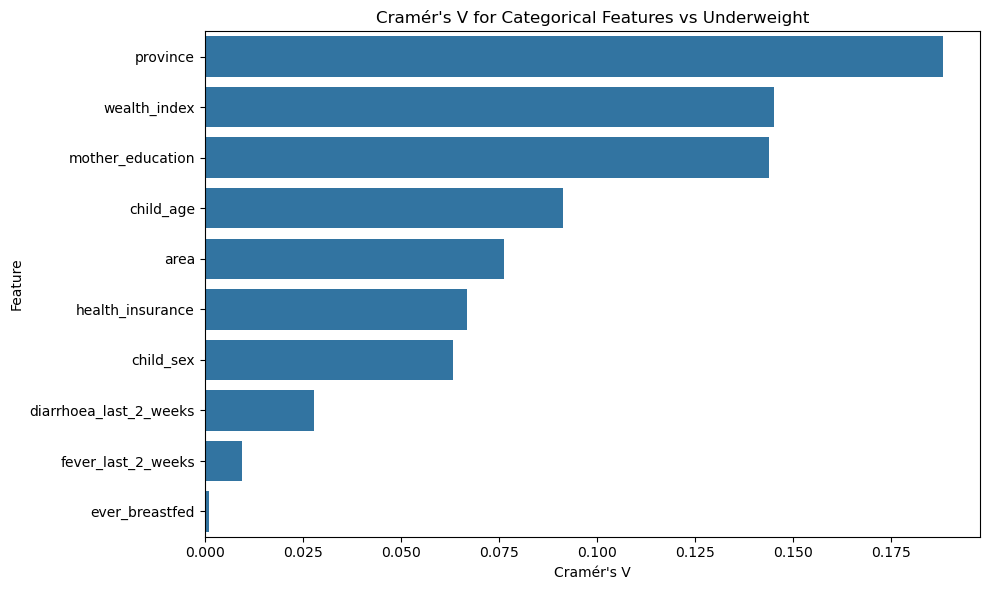

In [37]:
# Cramér's V values
cramers_v_df = pd.DataFrame.from_dict(cramers_v_results, orient='index', columns=['Cramér\'s V'])
cramers_v_df = cramers_v_df.sort_values(by='Cramér\'s V', ascending=False)
cramers_v_df.reset_index(inplace=True)
cramers_v_df.columns = ['Feature', 'Cramér\'s V']
# cramers_v_df.to_csv('/workspaces/malnutrition/MICS/cramers_v_results.csv', index=False)

# Plotting Cramér's V values
plt.figure(figsize=(10, 6))
sns.barplot(x='Cramér\'s V', y='Feature', data=cramers_v_df)
plt.title("Cramér's V for Categorical Features vs Underweight")
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Logistic Regression

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from collections import Counter

X = df2.drop(columns=['malnurished'])
y = df2['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)


In [42]:
# sm = SMOTE(random_state=42)
# X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
# print('Before SMOTE: ', Counter(y_train))
# print('After SMOTE: ', Counter(y_train_sm))

In [40]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.79      0.76       397
           1       0.71      0.65      0.68       320

    accuracy                           0.73       717
   macro avg       0.72      0.72      0.72       717
weighted avg       0.72      0.73      0.72       717



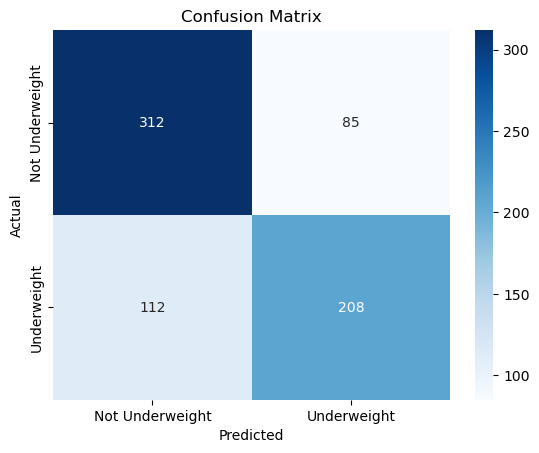

In [43]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Underweight', 'Underweight'], yticklabels=['Not Underweight', 'Underweight'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [44]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

y_probas = model.predict_proba(X_test)[:, 1]

print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.7005046836846038


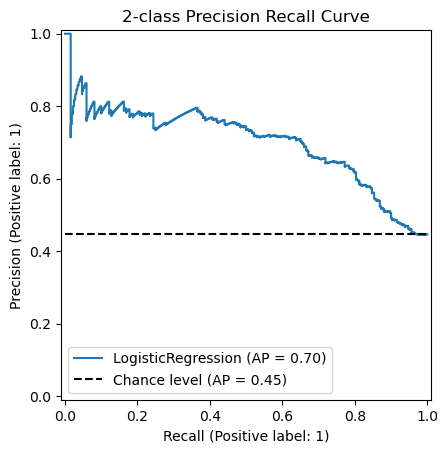

In [45]:
display = PrecisionRecallDisplay.from_estimator(
    model,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

---

